<a href="https://colab.research.google.com/github/robertbarcik/vector_databases-tutorial/blob/main/1.%20ChromaDB/4_Hybrid_Search_and_Reranking_with_ChromaDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Search and Reranking with ChromaDB

Notebook 3 ended with a store of chunks and a `query()` that finds the right paragraph for most questions. *Most* is the word to watch. Embeddings match on **meaning**, and meaning is exactly what an identifier such as `SA-2026-0117` or `800-207` does not have: to the model it is a handful of rare word pieces, and two advisories that differ only in their number look nearly the same. Keyword search has the opposite blind spot: it finds the exact string and misses every paraphrase.

This notebook puts the two side by side, combines them, and measures the result instead of trusting the architecture diagram. Eight parts: the corpus with a small **synthetic extension** full of confusable identifiers; an **evaluation set** with relevance labels written before any search is run; the **dense** baseline; **BM25** keyword search; **hybrid** retrieval with Reciprocal Rank Fusion; a **cross-encoder** that reranks the hybrid candidates; a **fair comparison** of the four pipelines; and an optional RAG comparison plus exercises. Everything except the optional last section runs on a CPU with free local models.

## Setup

Two local models are downloaded once: Chroma's default embedding model (`all-MiniLM-L6-v2`, about 80 MB, the same one as in notebooks 1 to 3) and a small cross-encoder for section 6 (about 90 MB). `rank-bm25` is a pure-Python BM25 implementation. Only section 8 calls OpenAI; the key lookup goes Colab secret, then environment variable, then a prompt (press Enter to skip).

In [ ]:
%pip install -q chromadb==1.5.5 sentence-transformers==5.3.0 rank-bm25==0.2.2 tiktoken==0.12.0 openai==2.28.0 pandas matplotlib   # Colab installs here; locally, `pip install -r requirements.txt` in the course folder already covers it

import os, re, json, time, pathlib, platform, subprocess, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken

try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    try:
        from getpass import getpass
        api_key = getpass("OpenAI API key (press Enter to skip section 8): ")
    except Exception:                      # no interactive input available (headless execution)
        api_key = ""
os.environ["OPENAI_API_KEY"] = api_key or ""

RAW = "https://raw.githubusercontent.com/dmicanek/GenAI-vector_databases-tutorial/refs/heads/main/1.%20ChromaDB/"
if not pathlib.Path("cyber_documents.json").exists():
    urllib.request.urlretrieve(RAW + "cyber_documents.json", "cyber_documents.json")

os.environ["ANONYMIZED_TELEMETRY"] = "False"     # keep Chroma's usage telemetry quiet
os.environ["HF_HUB_VERBOSITY"] = "error"          # and the Hugging Face download chatter
import chromadb
from chromadb.utils import embedding_functions
from rank_bm25 import BM25Okapi
import torch, transformers
transformers.logging.set_verbosity_error(); transformers.utils.logging.disable_progress_bar()
from sentence_transformers import CrossEncoder

enc = tiktoken.get_encoding("cl100k_base")
SETUP_COST = {}          # one-off costs in seconds (model loading, indexing); reported separately from query latency
print("Ready. chromadb", chromadb.__version__, "| torch", torch.__version__, "| threads", torch.get_num_threads())

Note: you may need to restart the kernel to use updated packages.


/home/micandan/.hermes/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready. chromadb 1.5.5 | torch 2.14.0+cu130 | threads 8


## 1. The corpus: six articles plus a synthetic extension

The six cybersecurity articles from `cyber_documents.json` stay exactly as they were. They are good at explaining ideas and bad at exposing the weakness we want to study: they contain few exact identifiers, and no two passages are confusable. Real knowledge bases are full of both: advisories that share a template and differ in one number, policies cited by id from other documents, incident reports that mention the same products as the manuals.

So we add **four short synthetic documents**, marked `source: "synthetic"` in their metadata: two security advisories written from the same template (OpenVPN and WireGuard), a patch policy that both advisories cite, and an incident report about a phishing wave stopped by MFA. Every identifier in them is invented for this lab. Together with the originals (`source: "course"`) that is ten documents.

In [2]:
documents = json.load(open("cyber_documents.json"))
for d in documents:
    d["metadata"] = {**d["metadata"], "source": "course"}

SYNTHETIC = [   # invented for this notebook: identifiers, versions and dates are fictional
    {"id": "document_7", "title": "Advisory SA-2026-0117: OpenVPN client",
     "metadata": {"category": "advisory", "year": 2026, "difficulty": "intermediate", "author": "Security Team", "source": "synthetic"},
     "text": "Security advisory SA-2026-0117 concerns the OpenVPN 2.6 client installed on all company laptops. The flaw, tracked as CVE-2026-4471, lets a malicious server skip the tls-auth handshake check, so a rogue Wi-Fi hotspot can present itself as the corporate VPN gateway and read the traffic that follows. Severity is rated high (CVSS 8.1). Affected versions: 2.6.0 through 2.6.12. The fix for SA-2026-0117 is version 2.6.13. Workaround until the fix is installed: pin the gateway certificate fingerprint in the client profile and disable the 'accept any server' option. Under policy POL-SEC-012 the fix must be installed within fourteen days of publication. Questions go to ticket queue NET-VPN."},
    {"id": "document_8", "title": "Advisory SA-2026-0121: WireGuard client",
     "metadata": {"category": "advisory", "year": 2026, "difficulty": "intermediate", "author": "Security Team", "source": "synthetic"},
     "text": "Security advisory SA-2026-0121 concerns the WireGuard client that the mobile device management profile installs on company phones. The flaw, tracked as CVE-2026-5188, lets a peer whose key has expired keep an established tunnel open for up to 180 seconds after key rotation, because the client does not re-check key expiry on handshake retries. Severity is rated medium (CVSS 5.3). Affected versions: mobile client builds before 1.0.2026.0901. The fix for SA-2026-0121 is build 1.0.2026.0915. There is no workaround; devices receive the fixed build automatically through mobile device management. Under policy POL-SEC-012 the fix must be installed within thirty days of publication. Questions go to ticket queue NET-VPN."},
    {"id": "document_9", "title": "Policy POL-SEC-012: patch deadlines",
     "metadata": {"category": "policy", "year": 2025, "difficulty": "beginner", "author": "Security Team", "source": "synthetic"},
     "text": "Policy POL-SEC-012 sets the deadlines for installing security fixes. Critical vulnerabilities (CVSS 9.0 and above) must be patched within 72 hours of the advisory. High vulnerabilities (CVSS 7.0 to 8.9) must be patched within fourteen days, medium ones (CVSS 4.0 to 6.9) within thirty days, and low ones within ninety days. A system that cannot be patched in time needs a written exception approved by the security officer and recorded in the risk register together with a compensating control. An emergency patch outside the regular change window needs approval in ticket queue CHG-EMERGENCY. POL-SEC-012 is reviewed every year and replaces the earlier document POL-SEC-007."},
    {"id": "document_10", "title": "Incident IR-2026-0042: payroll phishing wave",
     "metadata": {"category": "incident", "year": 2026, "difficulty": "beginner", "author": "Security Team", "source": "synthetic"},
     "text": "Incident IR-2026-0042 began on 3 March 2026, when eleven employees in the finance department received an email that pretended to come from the payroll provider. The message asked them to 'confirm your bank details before the March payment run' through a link to a look-alike domain. Two employees entered their credentials on the fake page. Both accounts were protected by MFA with an authenticator app, so the attacker's login attempts from an unfamiliar country were blocked. The security team reset the two passwords, blocked the domain on the email gateway and added the lure to the awareness-training examples. Lesson learned: the DMARC policy of the spoofed sender domain was set to 'none', which is why the message passed the gateway; the provider was asked to move it to 'reject'. Incident IR-2026-0042 was closed on 10 March 2026."},
]
documents = documents + SYNTHETIC

TEXT = {d["id"]: d["text"] for d in documents}
TITLE = {d["id"]: d["title"] for d in documents}

print(len(documents), "documents\n")
for d in documents:
    print(f"{d['id']:<12} {d['title']:<45} {d['metadata']['source']:<10} {len(enc.encode(d['text'])):>4} tokens")

10 documents

document_1   Public-key cryptography                       course      538 tokens
document_2   Stuxnet                                       course      442 tokens
document_3   Zero Trust Architecture                       course      450 tokens
document_4   Phishing                                      course      483 tokens
document_5   Multi-Factor Authentication                   course      305 tokens
document_6   Virtual Private Networks                      course      260 tokens
document_7   Advisory SA-2026-0117: OpenVPN client         synthetic   172 tokens
document_8   Advisory SA-2026-0121: WireGuard client       synthetic   170 tokens
document_9   Policy POL-SEC-012: patch deadlines           synthetic   155 tokens
document_10  Incident IR-2026-0042: payroll phishing wave  synthetic   181 tokens


### Chunking: the same splitter, the same settings

The token-window splitter from notebook 3, with **chunk size 100 and overlap 20**, fixed for the whole notebook. We are comparing retrieval methods, so the rows they retrieve must be identical; tuning the chunking at the same time would make every difference ambiguous. Chunk ids (`document_7#1`), the parent `doc_id`, the title and the `source` flag are stored as before, so every result can be traced back to its document.

The chunks go into their own collection, `cyber_chunks_hybrid`, so that `cyber_chunks` from notebook 3 stays untouched. The cell is safe to re-run: if the collection already holds exactly these chunk ids it is reused, otherwise it is rebuilt.

In [3]:
CHUNK_SIZE, OVERLAP = 100, 20

def chunk_by_tokens(text, chunk_size, overlap=0):
    """Fixed-size windows over the token sequence; consecutive windows share `overlap` tokens."""
    tokens = enc.encode(text)
    step = chunk_size - overlap
    chunks, start = [], 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunks.append({"start": start, "end": end, "text": enc.decode(tokens[start:end])})
        if end == len(tokens):
            break
        start += step
    return chunks

chunks = []
for d in documents:
    for i, c in enumerate(chunk_by_tokens(d["text"], CHUNK_SIZE, OVERLAP)):
        chunks.append({"id": f"{d['id']}#{i}", "text": c["text"],
                       "metadata": {**d["metadata"], "doc_id": d["id"], "title": d["title"], "chunk": i, "start": c["start"], "end": c["end"]}})

CHUNK_TEXT = {c["id"]: c["text"] for c in chunks}
CHUNK_META = {c["id"]: c["metadata"] for c in chunks}
CHUNK_IDS = list(CHUNK_TEXT)
assert len(CHUNK_IDS) == len(chunks), "chunk ids must be unique"

embed_local = embedding_functions.DefaultEmbeddingFunction()
chroma = chromadb.PersistentClient(path="./chroma_db")
NAME = "cyber_chunks_hybrid"

t0 = time.perf_counter()
collection = chroma.get_or_create_collection(name=NAME, embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}})
if set(collection.get(include=[])["ids"]) != set(CHUNK_IDS):          # empty, or built from a different corpus: rebuild
    chroma.delete_collection(NAME)
    collection = chroma.create_collection(name=NAME, embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}})
    collection.add(ids=CHUNK_IDS, documents=[c["text"] for c in chunks], metadatas=[c["metadata"] for c in chunks])
    SETUP_COST["embed + index chunks (Chroma)"] = time.perf_counter() - t0
    print(f"built '{NAME}' in {SETUP_COST['embed + index chunks (Chroma)']:.1f} s")

print(f"{len(documents)} documents -> {collection.count()} chunks in '{NAME}'")
print("chunks per document:", {d["id"]: sum(1 for c in chunks if c["metadata"]["doc_id"] == d["id"]) for d in documents})

10 documents -> 41 chunks in 'cyber_chunks_hybrid'
chunks per document: {'document_1': 7, 'document_2': 6, 'document_3': 6, 'document_4': 6, 'document_5': 4, 'document_6': 3, 'document_7': 2, 'document_8': 2, 'document_9': 2, 'document_10': 3}


## 2. A small evaluation set, labelled before searching

To say that one retrieval method is better than another we need questions with known answers. Eighteen questions, three kinds:

- **semantic**: a paraphrase that shares few or no key words with the passage that answers it;
- **lexical**: an exact identifier or term carries the question (`SA-2026-0117`, `800-207`, `Realtek`);
- **mixed**: an identifier plus a paraphrased fact.

Each question names the document and a short **evidence span**, a verbatim phrase from the sentence that answers it. The relevant chunk ids are *derived* from that span: every chunk whose text contains it. That is deliberate. With 20 tokens of overlap the same sentence often sits in two neighbouring chunks, and both are legitimate hits; deriving the labels from the text also means nobody looked at retrieval results before deciding what counts as correct. The `why` column records the judgment in one line.

Half of the questions are the **development set** (`dev`): anything we tune, we tune on those. The other half is **held out** and is touched exactly once, in section 7.

In [4]:
EVAL = [
    # ---- semantic: paraphrases -----------------------------------------------------------------------------------
    dict(id="Q01", split="dev",      kind="semantic", doc="document_2", question="How can software alone cause physical damage to machinery?",
         evidence="alter the rotational speed of the centrifuges", why="Stuxnet's payload in other words; 'software', 'machinery', 'damage' do not occur in the article."),
    dict(id="Q02", split="held-out", kind="semantic", doc="document_3", question="Why should being inside the office network not earn a laptop automatic trust?",
         evidence="no user or device can be implicitly trusted based on its physical or network location", why="Zero Trust in everyday words; 'office', 'laptop', 'earn' never appear."),
    dict(id="Q03", split="dev",      kind="semantic", doc="document_4", question="What makes people fall for fake messages?",
         evidence="exploit powerful human emotions such as fear, urgency, curiosity, or greed", why="'fake messages' stands for phishing lures; the answer is the sentence about emotions."),
    dict(id="Q04", split="held-out", kind="semantic", doc="document_5", question="If someone steals my password, why can they still be locked out?",
         evidence="they would still need access to your phone to complete the login", why="The MFA bank example; 'locked out' is nowhere in the text."),
    dict(id="Q05", split="dev",      kind="semantic", doc="document_1", question="Could a new kind of computer break today's encryption?",
         evidence="rise of quantum computing poses a significant future threat", why="Quantum computing is not named in the question."),
    dict(id="Q06", split="held-out", kind="semantic", doc="document_6", question="Is it safe to do online banking on a coffee-shop network?",
         evidence="data transmitted over public Wi-Fi can be intercepted", why="'coffee-shop network' means public Wi-Fi; 'banking' is a distractor that also occurs in the MFA article."),
    # ---- lexical: an exact identifier or term ---------------------------------------------------------------------
    dict(id="Q07", split="dev",      kind="lexical", doc="document_7", question="What is the fixed version in SA-2026-0117?",
         evidence="The fix for SA-2026-0117 is version 2.6.13", why="Only the advisory id separates it from SA-2026-0121, which follows the same template."),
    dict(id="Q08", split="held-out", kind="lexical", doc="document_8", question="What CVSS score was assigned to CVE-2026-5188?",
         evidence="Severity is rated medium (CVSS 5.3)", why="The CVE id is the only clue; both advisories carry a CVSS score."),
    dict(id="Q09", split="dev",      kind="lexical", doc="document_9", question="Which document did POL-SEC-012 replace?",
         evidence="replaces the earlier document POL-SEC-007", why="POL-SEC-012 is cited in both advisories too; only the policy says what it replaced."),
    dict(id="Q10", split="held-out", kind="lexical", doc="document_10", question="When was IR-2026-0042 closed?",
         evidence="IR-2026-0042 was closed on 10 March 2026", why="An identifier and a date."),
    dict(id="Q11", split="dev",      kind="lexical", doc="document_3", question="What does SP 800-207 cover?",
         evidence="Special Publication 800-207", why="The NIST number is the whole question; Zero Trust is not mentioned."),
    dict(id="Q12", split="held-out", kind="lexical", doc="document_2", question="What role did Realtek and JMicron play in Stuxnet?",
         evidence="Realtek and JMicron", why="Two company names that occur once in the corpus."),
    # ---- mixed: identifier plus paraphrase ------------------------------------------------------------------------
    dict(id="Q13", split="dev",      kind="mixed", doc="document_9", question="Under POL-SEC-012, how fast must a critical hole be closed?",
         evidence="patched within 72 hours", why="'critical hole ... closed' paraphrases 'critical vulnerabilities ... patched'; the advisories cite the same policy id."),
    dict(id="Q14", split="held-out", kind="mixed", doc="document_7", question="Is there a temporary fix for SA-2026-0117 before patching?",
         evidence="pin the gateway certificate fingerprint", why="'temporary fix' stands for 'workaround'; the WireGuard advisory explicitly has none."),
    dict(id="Q15", split="dev",      kind="mixed", doc="document_8", question="Which advisory cannot be worked around and relies on automatic updates?",
         evidence="There is no workaround", why="No identifier; both advisories talk about workarounds and updates, only one says there is none."),
    dict(id="Q16", split="held-out", kind="mixed", doc="document_10", question="How did MFA help during IR-2026-0042?",
         evidence="login attempts from an unfamiliar country were blocked", why="The MFA article also says MFA blocks attacks; the incident id selects the report."),
    dict(id="Q17", split="dev",      kind="mixed", doc="document_9", question="Which ticket queue approves an urgent patch outside the change window?",
         evidence="ticket queue CHG-EMERGENCY", why="'ticket queue' also appears in both advisories (NET-VPN); 'urgent' paraphrases 'emergency'."),
    dict(id="Q18", split="held-out", kind="mixed", doc="document_6", question="Which tunnelling protocols can a VPN be built on?",
         evidence="OpenVPN, WireGuard, and IKEv2/IPSec", why="The synthetic advisories mention OpenVPN and WireGuard too; only the VPN article lists the protocols."),
]

for item in EVAL:
    assert item["evidence"] in TEXT[item["doc"]], f"{item['id']}: evidence span is not verbatim in {item['doc']}"
    item["relevant"] = sorted(cid for cid in CHUNK_IDS if CHUNK_META[cid]["doc_id"] == item["doc"] and item["evidence"] in CHUNK_TEXT[cid])
    assert item["relevant"], f"{item['id']}: no chunk contains the evidence span whole"
    assert set(item["relevant"]) <= set(collection.get(include=[])["ids"]), f"{item['id']}: relevant id missing from the collection"

DEV = [q for q in EVAL if q["split"] == "dev"]
HELD_OUT = [q for q in EVAL if q["split"] == "held-out"]
assert len(DEV) == len(HELD_OUT) == 9 and {q["kind"] for q in DEV} == {q["kind"] for q in HELD_OUT}

pd.set_option("display.max_colwidth", None); pd.set_option("display.width", 200)
labels = pd.DataFrame([{"id": q["id"], "split": q["split"], "kind": q["kind"], "question": q["question"],
                        "relevant chunks": ", ".join(q["relevant"]), "why": q["why"]} for q in EVAL]).set_index("id")
print(f"{len(EVAL)} questions, {len(DEV)} dev + {len(HELD_OUT)} held-out;",
      sum(len(q["relevant"]) > 1 for q in EVAL), "questions have their evidence in two overlapping chunks")
labels

18 questions, 9 dev + 9 held-out; 3 questions have their evidence in two overlapping chunks


,split,kind,question,relevant chunks,why
id,,,,,
Q01,dev,semantic,How can software alone cause physical damage to machinery?,document_2#3,"Stuxnet's payload in other words; 'software', 'machinery', 'damage' do not occur in the article."
Q02,held-out,semantic,Why should being inside the office network not earn a laptop automatic trust?,document_3#1,"Zero Trust in everyday words; 'office', 'laptop', 'earn' never appear."
Q03,dev,semantic,What makes people fall for fake messages?,"document_4#1, document_4#2",'fake messages' stands for phishing lures; the answer is the sentence about emotions.
Q04,held-out,semantic,"If someone steals my password, why can they still be locked out?",document_5#1,The MFA bank example; 'locked out' is nowhere in the text.
Q05,dev,semantic,Could a new kind of computer break today's encryption?,document_1#5,Quantum computing is not named in the question.
Q06,held-out,semantic,Is it safe to do online banking on a coffee-shop network?,document_6#1,'coffee-shop network' means public Wi-Fi; 'banking' is a distractor that also occurs in the MFA article.
Q07,dev,lexical,What is the fixed version in SA-2026-0117?,document_7#1,"Only the advisory id separates it from SA-2026-0121, which follows the same template."
Q08,held-out,lexical,What CVSS score was assigned to CVE-2026-5188?,document_8#0,The CVE id is the only clue; both advisories carry a CVSS score.
Q09,dev,lexical,Which document did POL-SEC-012 replace?,document_9#1,POL-SEC-012 is cited in both advisories too; only the policy says what it replaced.


### 🔍 What just happened?

Eighteen questions, each tied to one or two chunk ids by a phrase that provably sits in the text. Look at the questions with two relevant chunks: the evidence fell into the 20-token overlap, so both neighbours hold it. A metric that demanded *both* would reward redundancy; ours (section 7) counts the evidence as found when *either* is retrieved.

This is the smallest evaluation set that still teaches something. Eighteen questions cannot separate two methods that differ by one hit, and every conclusion below should be read with that in mind. The point of the lab is the *procedure*: label first, split, tune on one half, report on the other.

## 3. Dense retrieval: the baseline

`collection.query()` from notebook 2, now wrapped in a function that returns `(chunk_id, distance)` pairs, best first. The collection was created with `space: cosine`, so the number is the **cosine distance**: `1 - cosine similarity`, between 0 (same direction) and 2 (opposite), and **smaller is closer**. Ties are broken by chunk id so that the output is reproducible.

In [5]:
def dense_search(query, k=3):
    """Nearest chunks by cosine distance of the embeddings (Chroma). Returns [(chunk_id, distance)], best first."""
    r = collection.query(query_texts=[query], n_results=k, include=["distances"])
    hits = sorted(zip(r["ids"][0], r["distances"][0]), key=lambda h: (h[1], h[0]))
    return [(cid, float(dist)) for cid, dist in hits[:k]]

def show(hits, score_name="distance", relevant=()):
    for rank, (cid, score) in enumerate(hits, start=1):
        m = CHUNK_META[cid]
        print(f"{rank}. {'✓' if cid in relevant else ' '} {cid:<14} {score_name} {score:7.3f}   {m['title']}")
        print(f"       {CHUNK_TEXT[cid].strip()[:105]}...")

for q in [EVAL[0], EVAL[6]]:                     # Q01 (semantic) and Q07 (lexical), both from the dev set
    print(f"❓ {q['id']} ({q['kind']}): {q['question']}   relevant: {q['relevant']}")
    show(dense_search(q["question"], 3), relevant=q["relevant"]); print()

❓ Q01 (semantic): How can software alone cause physical damage to machinery?   relevant: ['document_2#3']
1. ✓ document_2#3   distance   0.528   Stuxnet
       back to the human operators, creating the illusion that everything was functioning correctly. Meanwhile, ...
2.   document_2#2   distance   0.551   Stuxnet
       USB flash drives, exploiting a Windows Shell vulnerability related to .LNK files. Once inside a network, ...
3.   document_2#4   distance   0.670   Stuxnet
       different zero-day vulnerabilities in Microsoft Windows, a record for a single piece of malware at the ti...

❓ Q07 (lexical): What is the fixed version in SA-2026-0117?   relevant: ['document_7#1']
1.   document_8#1   distance   0.517   Advisory SA-2026-0121: WireGuard client
       5.3). Affected versions: mobile client builds before 1.0.2026.0901. The fix for SA-2026-0121 is build 1.0...
2. ✓ document_7#1   distance   0.567   Advisory SA-2026-0117: OpenVPN client
       ). Affected versions: 2.6.0 through 

### 🔍 What just happened?

The paraphrase question found the Stuxnet payload without sharing a single key word with it: that is what embeddings are for. The identifier question is the other story. The chunk that answers it came **second**, behind the corresponding sentence of the *other* advisory. The two advisories are written from one template, and the embedding model reads `SA-2026-0117` as a few rare word pieces that barely move the vector; what decides the order is the surrounding wording ("fix", "version", "affected versions"), which both chunks share. The distances agree: the top two are a few hundredths apart. A user who typed the exact advisory id would not accept "the other advisory" as the first hit.

## 4. Lexical retrieval with BM25

**BM25** is the ranking function behind classic search engines. It scores a chunk by how often the query's words occur in it (term frequency, with diminishing returns), how rare each word is across the corpus (rare words such as `800-207` weigh much more than `the`), and how long the chunk is (a hit in a short chunk counts more). No vectors, no model, a few kilobytes of statistics; `rank_bm25` builds it over the same chunk texts in milliseconds.

Everything hinges on **tokenization**: BM25 can only match tokens that exist in both the query and the chunk. A naive "letters only" tokenizer turns `800-207` into `800` and `207` and drops `2.6.13` entirely. Ours keeps digits and lets hyphens and dots join a token, so identifiers survive as single terms. We do no stemming, so `certificate` and `certificates` are different words; that is a real limitation you will meet in the mini-task.

In [6]:
def tokenize(text):
    """Lower-case; keep letters and digits; '-' and '.' inside a token keep identifiers such as 800-207 and 2.6.13 whole."""
    return re.findall(r"[a-z0-9]+(?:[-.][a-z0-9]+)*", text.lower())

naive_tokenize = lambda text: re.findall(r"[a-z]+", text.lower())

sample = "NIST SP 800-207; advisory SA-2026-0117 (CVSS 8.1), fixed in 2.6.13; IKEv2/IPSec and .LNK files"
print("naive:", naive_tokenize(sample))
print("ours: ", tokenize(sample))

t0 = time.perf_counter()
bm25 = BM25Okapi([tokenize(CHUNK_TEXT[cid]) for cid in CHUNK_IDS])
SETUP_COST["BM25 index"] = time.perf_counter() - t0

def bm25_search(query, k=3):
    """BM25 over the same chunks. A chunk that shares no term with the query is not a hit. Returns [(chunk_id, score)], best first."""
    scores = bm25.get_scores(tokenize(query))
    hits = [(cid, float(s)) for cid, s in zip(CHUNK_IDS, scores) if s > 0]
    hits.sort(key=lambda h: (-h[1], h[0]))
    return hits[:k]

print(f"\nBM25 index over {len(CHUNK_IDS)} chunks built in {SETUP_COST['BM25 index'] * 1000:.1f} ms")

naive: ['nist', 'sp', 'advisory', 'sa', 'cvss', 'fixed', 'in', 'ikev', 'ipsec', 'and', 'lnk', 'files']
ours:  ['nist', 'sp', '800-207', 'advisory', 'sa-2026-0117', 'cvss', '8.1', 'fixed', 'in', '2.6.13', 'ikev2', 'ipsec', 'and', 'lnk', 'files']

BM25 index over 41 chunks built in 2.0 ms


In [7]:
for q in [EVAL[6], EVAL[0]]:                     # the same two questions as in section 3, Q07 then Q01
    print(f"❓ {q['id']} ({q['kind']}): {q['question']}   relevant: {q['relevant']}")
    print("   query tokens:", tokenize(q["question"]))
    show(bm25_search(q["question"], 3), score_name="BM25 ", relevant=q["relevant"]); print()

❓ Q07 (lexical): What is the fixed version in SA-2026-0117?   relevant: ['document_7#1']
   query tokens: ['what', 'is', 'the', 'fixed', 'version', 'in', 'sa-2026-0117']
1. ✓ document_7#1   BM25    9.755   Advisory SA-2026-0117: OpenVPN client
       ). Affected versions: 2.6.0 through 2.6.12. The fix for SA-2026-0117 is version 2.6.13. Workaround until ...
2.   document_8#1   BM25    6.335   Advisory SA-2026-0121: WireGuard client
       5.3). Affected versions: mobile client builds before 1.0.2026.0901. The fix for SA-2026-0121 is build 1.0...
3.   document_7#0   BM25    5.294   Advisory SA-2026-0117: OpenVPN client
       Security advisory SA-2026-0117 concerns the OpenVPN 2.6 client installed on all company laptops. The flaw...

❓ Q01 (semantic): How can software alone cause physical damage to machinery?   relevant: ['document_2#3']
   query tokens: ['how', 'can', 'software', 'alone', 'cause', 'physical', 'damage', 'to', 'machinery']
1.   document_2#0   BM25    7.068   Stuxnet
    

### 🔍 What just happened?

For the identifier question BM25 is precise: `sa-2026-0117` occurs in exactly one document, so its inverse document frequency is high, and the chunk that has it together with "fixed" and "version" wins by a wide margin. The WireGuard advisory, which the embedding model preferred, is second on the strength of "fixed" and a handful of common words; the OpenVPN advisory's opening chunk, which has the id but not the version, is third. The score is not a distance and not a probability; it is a sum of per-term weights that grows with the number of matching terms, so it is only comparable *within* one query.

For the paraphrase question BM25 has nothing to work with. The query words that do occur in the corpus (`can`, `physical`, `damage`, `software`) are common or point at the wrong passage, and the chunk with the answer never mentions software or machinery. Both methods are right about something and blind to something, and they are blind to different things. That is the case for combining them.

### 🎯 Mini-task

Ask `bm25_search` for "stolen certificate" and then for "stolen certificates". Explain the difference, then write a `tokenize_stemmed` that strips a trailing `s` from tokens longer than three letters, rebuild the index, and check what it does to the two queries.

In [8]:
# YOUR CODE HERE

## 5. Hybrid retrieval with Reciprocal Rank Fusion

We have two ranked lists per query. Why not add the scores? Because they live on different scales with opposite directions: a cosine distance between 0 and 2 where smaller is better, a BM25 score between 0 and roughly 15 where larger is better, and the BM25 range changes from query to query with the rarity of the words. Any weighted sum would need per-query normalisation, and with a handful of results the normalisation is as noisy as the scores.

**Reciprocal Rank Fusion (RRF)** throws the scores away and keeps only the ranks:

$$\mathrm{RRF}(\text{chunk}) = \sum_{\text{lists}} \frac{1}{k + \text{rank}}$$

with one-based ranks and a constant $k$ (60 in the original paper). A chunk gets one term per list it appears in; a chunk absent from a list gets nothing from it. Being first in both lists beats being first in one, and a chunk ranked fifth in both often beats one ranked first in one and absent from the other. The constant $k$ controls how steeply the contribution decays with rank: small $k$ trusts the top of each list, large $k$ flattens the differences.

In [9]:
def rrf_fuse(ranked_lists, rrf_k=60):
    """ranked_lists: lists of chunk ids, best first. Returns [(chunk_id, fused_score)], best first, ties broken by id."""
    scores = {}
    for ranked in ranked_lists:
        for rank, cid in enumerate(ranked, start=1):                      # one-based rank
            scores[cid] = scores.get(cid, 0.0) + 1.0 / (rrf_k + rank)
    return sorted(scores.items(), key=lambda h: (-h[1], h[0]))

# Check against a hand computation: 'a' is 1st and 2nd, 'c' is 3rd and 1st, 'b' and 'd' appear in one list only.
fused = rrf_fuse([["a", "b", "c"], ["c", "a", "d"]], rrf_k=60)
expected = {"a": 1/61 + 1/62, "b": 1/62, "c": 1/63 + 1/61, "d": 1/63}
assert [cid for cid, _ in fused] == ["a", "c", "b", "d"], fused
assert all(abs(dict(fused)[cid] - v) < 1e-12 for cid, v in expected.items())
print("RRF check passed:", [(cid, round(s, 5)) for cid, s in fused])

DEPTH = 20                                   # candidate limit: how deep each retriever's list goes before fusion
RRF_K = 60                                   # the conventional constant; section 7 checks it on the dev set

def hybrid_search(query, k=3, depth=DEPTH, rrf_k=None):
    """Dense and BM25 lists (each up to `depth` long) fused with RRF. Returns [(chunk_id, fused_score)], best first."""
    rrf_k = RRF_K if rrf_k is None else rrf_k          # the global is re-chosen in section 7
    dense = [cid for cid, _ in dense_search(query, depth)]
    lexical = [cid for cid, _ in bm25_search(query, depth)]
    return rrf_fuse([dense, lexical], rrf_k)[:k]

RRF check passed: [('a', 0.03252), ('c', 0.03227), ('b', 0.01613), ('d', 0.01587)]


In [10]:
q = EVAL[12]                                  # Q13 (mixed, dev): a policy id plus a paraphrased fact
dense_rank = {cid: r for r, (cid, _) in enumerate(dense_search(q["question"], DEPTH), start=1)}
bm25_rank = {cid: r for r, (cid, _) in enumerate(bm25_search(q["question"], DEPTH), start=1)}
fused = rrf_fuse([list(dense_rank), list(bm25_rank)], RRF_K)

worked = pd.DataFrame([{"chunk": cid, "relevant": "✓" if cid in q["relevant"] else "",
                        "dense rank": dense_rank.get(cid, "–"), "BM25 rank": bm25_rank.get(cid, "–"),
                        "RRF score": round(score, 5), "final rank": r}
                       for r, (cid, score) in enumerate(fused[:8], start=1)]).set_index("final rank")
print(f"❓ {q['id']}: {q['question']}   relevant: {q['relevant']}")
print(f"   dense list: {len(dense_rank)} chunks, BM25 list: {len(bm25_rank)} chunks, fused: {len(fused)} chunks\n")
worked

❓ Q13: Under POL-SEC-012, how fast must a critical hole be closed?   relevant: ['document_9#0']
   dense list: 20 chunks, BM25 list: 20 chunks, fused: 27 chunks



,chunk,relevant,dense rank,BM25 rank,RRF score
final rank,,,,,
1,document_9#0,✓,1,2,0.03252
2,document_9#1,,2,5,0.03151
3,document_10#2,,4,4,0.03125
4,document_7#1,,9,3,0.03037
5,document_2#5,,3,10,0.03016
6,document_8#1,,15,1,0.02973
7,document_3#1,,7,19,0.02758
8,document_3#2,,19,8,0.02736


### 🔍 What just happened?

Read the table row by row. The policy's opening chunk, first for dense and second for BM25, collects two large terms and wins. Now look at `document_8#1`, the WireGuard advisory: BM25 put it **first** (it cites POL-SEC-012 and talks about installing a fix), dense put it fifteenth, and the fusion parked it in sixth place. A chunk that only one retriever liked collects one large term and one small one; a chunk that neither ranked in its top 20 is not in the table at all. The fused scores are small numbers with a narrow range (at $k = 60$ the first rank is worth $1/61 \approx 0.0164$ and the twentieth $1/80 = 0.0125$), which is fine: RRF is used for ordering, never for thresholds.

Two details worth remembering. The `depth` of the lists is a real parameter: a chunk ranked 21st by dense search does not exist for the fusion. And the BM25 list is often shorter than 20, because chunks with no shared term are not hits; when it is, the dense list decides the tail.

## 6. Cross-encoder reranking

Everything so far embedded the query and the chunks **separately**: the chunk vectors were computed at indexing time without knowing any question, and the query vector was computed without seeing any chunk. That is what makes vector search fast (compare a vector with a million precomputed ones) and also what limits it: the model never gets to read the question and the passage together.

A **cross-encoder** does exactly that. It takes the pair *(query, passage)* as one input, attends across both, and outputs one relevance score. It is far more accurate and far too slow to run over a whole corpus, so it is used as a second stage: retrieve a small pool of candidates cheaply, then rerank only those. We use `cross-encoder/ms-marco-MiniLM-L6-v2`, a 22-million-parameter model trained on the MS MARCO passage-ranking data, small enough to score a pair in a few milliseconds on a CPU.

In [11]:
t0 = time.perf_counter()
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2", device="cpu")
SETUP_COST["cross-encoder load"] = time.perf_counter() - t0
print(f"cross-encoder loaded in {SETUP_COST['cross-encoder load']:.1f} s | output activation: {type(reranker.activation_fn).__name__}")

query = "What is the fixed version in SA-2026-0117?"
pairs = [(query, CHUNK_TEXT["document_7#1"]), (query, CHUNK_TEXT["document_8#1"]), (query, CHUNK_TEXT["document_4#0"])]
for (qq, passage), score in zip(pairs, reranker.predict(pairs)):
    print(f"score {score:7.3f}   {passage.strip()[:90]}...")

cross-encoder loaded in 3.0 s | output activation: Identity
score   8.278   ). Affected versions: 2.6.0 through 2.6.12. The fix for SA-2026-0117 is version 2.6.13. Wo...
score   7.184   5.3). Affected versions: mobile client builds before 1.0.2026.0901. The fix for SA-2026-01...
score -11.324   Phishing is the most pervasive form of social engineering, an attack vector that targets t...


The scores are the model's raw output (logits): higher means more relevant, negative means "probably not", and the model was trained so that the right passage scores above the wrong ones *for the same query*. Here the right chunk wins, the look-alike WireGuard chunk is close behind, and the phishing chunk is far below. Notice how small the gap between the two advisories is compared with the gap to an unrelated passage: the cross-encoder also treats the identifier as a weak signal, it just weighs the rest of the wording better than the bi-encoder did. The scores are **not calibrated probabilities**. Squashing them through a sigmoid gives a number between 0 and 1, but 0.9 does not mean "90 % likely relevant" for your corpus, and a threshold that works on one set of questions can fail on another. Use them to order, and calibrate on your own data if you need a cut-off.

Now the reranking step itself: take the top candidates of the hybrid search (the pool), score every (query, chunk) pair, sort.

In [12]:
POOL = 10                                    # how many hybrid candidates the cross-encoder sees; section 7 checks it on the dev set

def rerank(query, candidate_ids, k=3):
    """Score every (query, chunk) pair with the cross-encoder and keep the best k. Returns [(chunk_id, score)]."""
    scores = reranker.predict([(query, CHUNK_TEXT[cid]) for cid in candidate_ids])
    hits = sorted(zip(candidate_ids, map(float, scores)), key=lambda h: (-h[1], h[0]))
    return hits[:k]

def hybrid_rerank_search(query, k=3, pool=None, rrf_k=None):
    """Hybrid retrieval, then cross-encoder reranking of the top `pool` candidates."""
    pool = POOL if pool is None else pool              # the global is re-chosen in section 7
    candidates = [cid for cid, _ in hybrid_search(query, k=pool, rrf_k=rrf_k)]
    return rerank(query, candidates, k)

for q in [EVAL[10], EVAL[14]]:                # Q11 (lexical, dev) and Q15 (mixed, dev)
    full = [cid for cid, _ in hybrid_search(q["question"], len(CHUNK_IDS))]
    where = next(r for r, cid in enumerate(full, start=1) if cid in q["relevant"])
    print(f"❓ {q['id']} ({q['kind']}, {q['split']}): {q['question']}   relevant: {q['relevant']}")
    print(f"   evidence sits at position {where} of the full fused list; the reranker sees the first {POOL}\n")
    print("hybrid candidates in RRF order, the reranker's pool:")
    show(hybrid_search(q["question"], POOL), score_name="RRF    ", relevant=q["relevant"])
    print("\nafter cross-encoder reranking, top 3:")
    show(hybrid_rerank_search(q["question"], 3), score_name="CE     ", relevant=q["relevant"]); print("\n")

❓ Q11 (lexical, dev): What does SP 800-207 cover?   relevant: ['document_3#4']
   evidence sits at position 2 of the full fused list; the reranker sees the first 10

hybrid candidates in RRF order, the reranker's pool:
1.   document_8#0   RRF       0.032   Advisory SA-2026-0121: WireGuard client
       Security advisory SA-2026-0121 concerns the WireGuard client that the mobile device management profile in...
2. ✓ document_3#4   RRF       0.032   Zero Trust Architecture
       level, and enforcing strict access controls between them. The National Institute of Standards and Technol...
3.   document_2#1   RRF       0.031   Stuxnet
       primary target was the Iranian nuclear program, specifically the Siemens industrial control systems (ICS)...
4.   document_9#1   RRF       0.016   Policy POL-SEC-012: patch deadlines
       ones within ninety days. A system that cannot be patched in time needs a written exception approved by th...
5.   document_2#5   RRF       0.016   Stuxnet
       a pr

### 🔍 What just happened?

Two different outcomes. For the NIST question the evidence was second in the fused list, behind a chunk of the WireGuard advisory, and the cross-encoder moved it to first with a clear positive score while everything else went deeply negative: reading "800-207" in the question next to "800-207" in the passage is exactly what a joint encoder is good at.

For the workaround question the reranker changed nothing that matters, because the chunk that says "There is no workaround" was **not in the pool**: the fused list had it in fifteenth place, and the reranker saw ten. Every candidate scored deeply negative, which is the model's way of saying that none of them answers the question. This is the built-in limit of a second stage: **a reranker only reorders what the first stage delivers**, so the recall of the first stage is a ceiling for the whole pipeline, and the pool size is a real parameter. The other limit is cost: ten pairs is ten forward passes per query, on top of the retrieval; twenty pairs is twenty.

### 🎯 Mini-task

Rerun the cell above with `POOL = 20`. Does the workaround question's evidence make it into the top 3 now, and what happens to the time per query? (`%%time` at the top of a cell measures it.)

In [13]:
# YOUR CODE HERE

## 7. Measuring: four pipelines, one protocol

Four pipelines, same corpus, same chunks, same labels, same questions, same final result count **K = 3**:

1. **dense**: Chroma nearest neighbours;
2. **BM25**: lexical only;
3. **hybrid**: dense and BM25 lists of depth 20, fused with RRF;
4. **hybrid + rerank**: the hybrid list, top `POOL` candidates rescored by the cross-encoder.

Two quality metrics, both computed per question on the top 3 and averaged:

- **Recall@3**: 1 if at least one relevant chunk (a chunk holding the evidence span) is in the top 3, else 0. With one evidence span per question this is the share of questions whose evidence was found; the "at least one" clause is what makes two overlapping copies of the same sentence count once.
- **MRR@3**: 1 divided by the rank of the first relevant chunk (1, ½ or ⅓), 0 if none is in the top 3. It rewards putting the evidence *first*, which matters when a prompt has room for one or two passages.

And one cost metric, **warm-query latency**: wall-clock time from the question string to the final ranked list of ids, measured with `time.perf_counter()` after one warm-up call, three rounds over all eighteen questions, reported as the median and the 95th percentile. It includes embedding the query, BM25 scoring, fusion and cross-encoder scoring; it excludes model downloads, model loading and index building, which are reported separately from `SETUP_COST`.

The parameters `RRF_K` and `POOL` are chosen on the dev set first. The held-out set is evaluated once, with those values, and nothing is changed afterwards.

In [14]:
K = 3

def recall_at_k(ranked, relevant, k=K):
    """1 if any relevant chunk is among the first k, else 0."""
    return float(any(cid in relevant for cid in ranked[:k]))

def mrr_at_k(ranked, relevant, k=K):
    """1 / rank of the first relevant chunk within the first k; 0 if there is none."""
    for rank, cid in enumerate(ranked[:k], start=1):
        if cid in relevant:
            return 1.0 / rank
    return 0.0

# checks on toy lists
assert recall_at_k(["x", "y", "z"], {"z"}) == 1.0 and recall_at_k(["x", "y", "z", "w"], {"w"}) == 0.0
assert mrr_at_k(["x", "y", "z"], {"y"}) == 0.5 and mrr_at_k(["x", "y", "z"], {"x", "y"}) == 1.0 and mrr_at_k(["x", "y", "z"], {"q"}) == 0.0
print("metric checks passed")

def evaluate(search, items, k=K):
    """Run `search(question, k)` for every item; return one row per question with both metrics."""
    rows = []
    for it in items:
        ranked = [cid for cid, _ in search(it["question"], k)]
        assert len(ranked) == len(set(ranked)) <= k, f"{it['id']}: duplicate ids or more than {k} results: {ranked}"
        assert set(ranked) <= set(CHUNK_IDS), f"{it['id']}: unknown chunk id in {ranked}"
        first = next((r for r, cid in enumerate(ranked, start=1) if cid in it["relevant"]), None)
        rows.append({"id": it["id"], "kind": it["kind"], "recall@3": recall_at_k(ranked, it["relevant"], k),
                     "mrr@3": mrr_at_k(ranked, it["relevant"], k), "first relevant": first, "returned": len(ranked), "top": ranked})
    return pd.DataFrame(rows).set_index("id")

def summary(df):
    return {"recall@3": round(float(df["recall@3"].mean()), 3), "mrr@3": round(float(df["mrr@3"].mean()), 3)}

print("dense on the dev set:", summary(evaluate(dense_search, DEV)))

metric checks passed
dense on the dev set: {'recall@3': 0.667, 'mrr@3': 0.556}


### Choosing `RRF_K` and `POOL` on the development set

A small sweep, scored by dev MRR@3. The tie-break rules are fixed in advance: for `RRF_K`, keep the conventional 60 if it is among the best, otherwise the smallest best value; for `POOL`, the smallest best value, because a smaller pool is cheaper.

In [15]:
sweep_k = pd.DataFrame([{"rrf_k": rk, **summary(evaluate(lambda qq, k, rk=rk: hybrid_search(qq, k, rrf_k=rk), DEV))} for rk in [10, 30, 60, 100]]).set_index("rrf_k")
best = sweep_k.index[sweep_k["mrr@3"] == sweep_k["mrr@3"].max()].tolist()
RRF_K = 60 if 60 in best else min(best)

sweep_pool = pd.DataFrame([{"pool": p, **summary(evaluate(lambda qq, k, p=p: hybrid_rerank_search(qq, k, pool=p, rrf_k=RRF_K), DEV))} for p in [5, 10, 20]]).set_index("pool")
POOL = int(min(sweep_pool.index[sweep_pool["mrr@3"] == sweep_pool["mrr@3"].max()]))

print("hybrid on dev, by rrf_k:"); print(sweep_k.to_string())
print(f"\n-> RRF_K = {RRF_K}\n")
print("hybrid + rerank on dev, by pool size:"); print(sweep_pool.to_string())
print(f"\n-> POOL = {POOL}")

hybrid on dev, by rrf_k:
       recall@3  mrr@3
rrf_k                 
10        0.667  0.611
30        0.667  0.611
60        0.667  0.611
100       0.667  0.611

-> RRF_K = 60

hybrid + rerank on dev, by pool size:
      recall@3  mrr@3
pool                 
5        0.778  0.778
10       0.778  0.778
20       1.000  0.852

-> POOL = 20


### The held-out comparison

Now the four pipelines on the nine held-out questions, evaluated once. The dev numbers are shown next to them for reference only; they are the numbers the parameters were fitted to and are expected to look better.

In [16]:
PIPELINES = {
    "dense":           dense_search,
    "BM25":            bm25_search,
    "hybrid (RRF)":    lambda qq, k: hybrid_search(qq, k, rrf_k=RRF_K),
    "hybrid + rerank": lambda qq, k: hybrid_rerank_search(qq, k, pool=POOL, rrf_k=RRF_K),
}

results = {name: {"held-out": evaluate(fn, HELD_OUT), "dev": evaluate(fn, DEV)} for name, fn in PIPELINES.items()}

comparison = pd.DataFrame({name: {"held-out recall@3": summary(r["held-out"])["recall@3"], "held-out MRR@3": summary(r["held-out"])["mrr@3"],
                                  "dev recall@3": summary(r["dev"])["recall@3"], "dev MRR@3": summary(r["dev"])["mrr@3"]}
                           for name, r in results.items()}).T
short = {name: int((r["held-out"]["returned"] < K).sum() + (r["dev"]["returned"] < K).sum()) for name, r in results.items()}
print("questions with fewer than 3 results (a BM25 list stops where no chunk shares a term):", short)
comparison

questions with fewer than 3 results (a BM25 list stops where no chunk shares a term): {'dense': 0, 'BM25': 0, 'hybrid (RRF)': 0, 'hybrid + rerank': 0}


,held-out recall@3,held-out MRR@3,dev recall@3,dev MRR@3
dense,0.778,0.574,0.667,0.556
BM25,0.778,0.667,0.556,0.444
hybrid (RRF),0.778,0.722,0.667,0.611
hybrid + rerank,0.889,0.759,1.000,0.852


In [17]:
def hardware():
    cpu = platform.processor() or platform.machine()
    try:
        if platform.system() == "Darwin":
            cpu = subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"], text=True).strip()
        else:
            cpu = next(line.split(":", 1)[1].strip() for line in open("/proc/cpuinfo") if line.startswith("model name"))
    except Exception:
        pass
    return f"{cpu}; {os.cpu_count()} logical cores; {platform.system()} {platform.machine()}; Python {platform.python_version()}; torch {torch.__version__} on CPU, {torch.get_num_threads()} threads"

def time_pipeline(search, items, rounds=3):
    """Warm-query latency in ms: one untimed warm-up call, then `rounds` passes over all questions."""
    search(items[0]["question"], K)
    samples = []
    for _ in range(rounds):
        for it in items:
            t0 = time.perf_counter(); search(it["question"], K); samples.append((time.perf_counter() - t0) * 1000)
    return {"median ms": round(float(np.median(samples)), 1), "p95 ms": round(float(np.percentile(samples, 95)), 1), "calls": len(samples)}

latency = pd.DataFrame({name: time_pipeline(fn, EVAL) for name, fn in PIPELINES.items()}).T
comparison["median latency ms"] = latency["median ms"]; comparison["p95 latency ms"] = latency["p95 ms"]

print("hardware:", hardware())
print("timing boundary: question string -> final list of 3 chunk ids; per call, warm; 3 rounds x 18 questions\n")
print("one-off setup costs (excluded from the latencies above):")
for name, seconds in SETUP_COST.items():
    print(f"  {name:<32} {seconds:8.2f} s")
print("  model downloads (first run only)   all-MiniLM-L6-v2 ~80 MB, cross-encoder ~90 MB\n")
comparison

hardware: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz; 16 logical cores; Linux x86_64; Python 3.11.5; torch 2.14.0+cu130 on CPU, 8 threads
timing boundary: question string -> final list of 3 chunk ids; per call, warm; 3 rounds x 18 questions

one-off setup costs (excluded from the latencies above):
  BM25 index                           0.00 s
  cross-encoder load                   3.02 s
  model downloads (first run only)   all-MiniLM-L6-v2 ~80 MB, cross-encoder ~90 MB



,held-out recall@3,held-out MRR@3,dev recall@3,dev MRR@3,median latency ms,p95 latency ms
dense,0.778,0.574,0.667,0.556,179.8,218.5
BM25,0.778,0.667,0.556,0.444,0.1,0.2
hybrid (RRF),0.778,0.722,0.667,0.611,186.8,243.3
hybrid + rerank,0.889,0.759,1.000,0.852,476.7,566.0


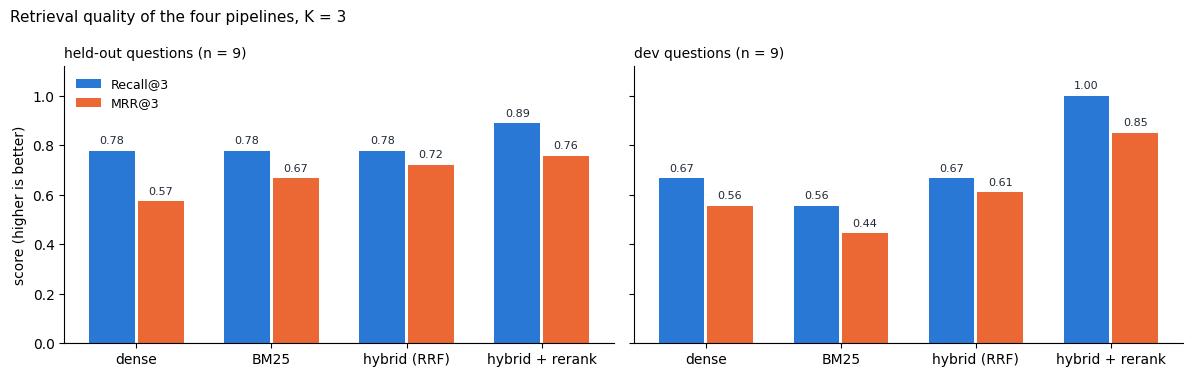

In [18]:
COLORS = {"recall@3": "#2a78d6", "mrr@3": "#eb6834"}
names = list(PIPELINES)
x = np.arange(len(names)); width = 0.36

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, split in [(ax1, "held-out"), (ax2, "dev")]:
    for j, metric in enumerate(["recall@3", "mrr@3"]):
        vals = [results[n][split][metric].mean() for n in names]
        bars = ax.bar(x + (j - 0.5) * width, vals, width * 0.94, color=COLORS[metric], label=metric.upper().replace("MRR", "MRR").replace("RECALL", "Recall"))
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#1F2937")
    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1.12)
    ax.set_title(f"{split} questions (n = {len(HELD_OUT) if split == 'held-out' else len(DEV)})", loc="left", fontsize=10)
    ax.axhline(0, color="#64748B", lw=0.8)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
ax1.set_ylabel("score (higher is better)"); ax1.legend(frameon=False, fontsize=9, loc="upper left")
plt.suptitle("Retrieval quality of the four pipelines, K = 3", x=0.01, ha="left", fontsize=11); plt.tight_layout(); plt.show()

Averages hide which questions moved. The per-question table shows, for every pipeline, the rank of the first relevant chunk (1 to 3) or a dash when the evidence is not in the top 3. Read across a row to see the four methods disagree on one question; read down a column to see a method's blind spot.

In [19]:
per_query = pd.DataFrame({name: pd.concat([r["dev"], r["held-out"]])["first relevant"] for name, r in results.items()})
per_query = per_query.reindex([q["id"] for q in EVAL]).map(lambda v: "–" if pd.isna(v) else str(int(v)))
per_query.insert(0, "kind", [q["kind"] for q in EVAL]); per_query.insert(1, "split", [q["split"] for q in EVAL])
per_query.insert(2, "question", [q["question"][:58] for q in EVAL])

print("rank of the first relevant chunk in the top 3 ('–' = not found)\n")
print(per_query.to_string())

by_kind = pd.DataFrame({name: pd.concat([r["dev"], r["held-out"]]).groupby("kind")["recall@3"].mean().round(2) for name, r in results.items()})
print("\nRecall@3 by question kind, all 18 questions:\n"); print(by_kind.to_string())

rank of the first relevant chunk in the top 3 ('–' = not found)

         kind     split                                                    question dense BM25 hybrid (RRF) hybrid + rerank
id                                                                                                                         
Q01  semantic       dev  How can software alone cause physical damage to machinery?     1    –            –               1
Q02  semantic  held-out  Why should being inside the office network not earn a lapt     3    –            –               3
Q03  semantic       dev                   What makes people fall for fake messages?     1    –            1               1
Q04  semantic  held-out  If someone steals my password, why can they still be locke     1    1            1               1
Q05  semantic       dev      Could a new kind of computer break today's encryption?     –    –            –               3
Q06  semantic  held-out   Is it safe to do online banking on a coff

### 🔍 What just happened?

**The averages first.** On the nine held-out questions dense, BM25 and hybrid all found the evidence for seven; they differ only in *where* they put it, which is what MRR@3 shows: hybrid ahead of BM25, BM25 ahead of dense. Hybrid + rerank found eight and puts the evidence first most often. With nine questions one hit moves Recall@3 by 0.11, so the recall tie is a tie and the MRR gaps are suggestive, not proven. The dev numbers of the reranked pipeline are higher than its held-out numbers, as expected: its pool size was chosen on them.

**Now read the rows.**

- **Identifiers.** On the six lexical questions BM25 is 6 for 6 and dense 5 for 6, with the evidence usually second or third behind a look-alike passage. Fusion inherits BM25's precision here: the exact term pulls the right chunk to first place (Q08, Q12) or from nowhere into the top 3 (Q14) without losing what dense found.
- **Paraphrases.** BM25 finds 1 of 6 (Q04, thanks to the shared words "steals" and "password"), and fusion pays for that: on Q01 and Q02 dense had the evidence in its top 3, BM25 voted for other chunks of the same article, and the fused list pushed the evidence to fifth and fourth place. **A retriever that is wrong about a question still gets a vote.** That is the price of RRF, and it is why hybrid recall is no better than dense recall on this set, on both halves.
- **The reranker repairs most of that** (Q01 back to first, Q05 and Q15 into the top 3 for the first time, Q11 and Q14 from second to first) because it reads the question together with the passage. It also **regresses** on Q18: the VPN article's opening chunk, which describes the encrypted tunnel, outscored the chunk that lists the protocols, and a question that the other three pipelines answered at rank 1 now sits at rank 2. On Q02 it restored dense's third place while scoring every candidate deeply negative: it did not like any of them.
- **Q06 defeats all four.** "Online banking on a coffee-shop network" is answered by the sentence about public Wi-Fi, but "banking" and "online" pull every method towards the MFA bank example and the VPN article's other chunks. No fusion or reranking helps when the question's vocabulary points elsewhere; rewriting the query (by hand or with the language model) is the tool for that failure.

**Latency** is the other axis. BM25 answers in a fraction of a millisecond. Dense and hybrid cost about the same, because embedding the query dominates and BM25 scoring plus fusion are free by comparison. The reranker adds twenty cross-encoder passes per query, roughly two and a half times the latency on this CPU, for an MRR gain that a prompt with room for three passages barely notices and a prompt with room for one notices a lot.

**Two things this dataset cannot tell you.** With 41 chunks and 18 questions one question is 6 percentage points, so differences of one or two hits are noise; a real evaluation needs a few hundred labelled questions, and the dev/held-out split matters more, not less, when the set is small. And the overlap from notebook 3 shows up in every list: the top 3 often holds two neighbouring chunks of the same article (dense on Q18 returns three chunks of the VPN article), so the third slot frequently carries text the model has already seen. De-duplicating by `doc_id` before the prompt is the usual fix and one of the exercises.

## 8. Optional: does better retrieval make a better answer?

Retrieval metrics say whether the evidence reached the prompt, not whether the model used it well. The only way to know is to generate. The cell below asks one held-out question twice with the same model, prompt and context budget (three chunks), once with the dense top 3 and once with the reranked top 3, and prints the sources under each answer so you can check the citations. Needs the OpenAI key; without it the cell says so and moves on.

In [ ]:
if not api_key:
    print("No OpenAI key entered: section 8 is skipped. Everything above ran without it.")
else:
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    MODEL = "gpt-5.6-luna"

    def build_prompt(question, hits):
        sources = "\n\n".join(f"[{i}] ({CHUNK_META[cid]['title']}, chunk {CHUNK_META[cid]['chunk']})\n{CHUNK_TEXT[cid].strip()}" for i, (cid, _) in enumerate(hits, start=1))
        return ("Answer the question using ONLY the sources below. Cite the sources you use as [1], [2], ...\n"
                "If the sources do not contain the answer, say: I don't have enough information.\n\n"
                f"SOURCES:\n{sources}\n\nQUESTION: {question}")

    q = EVAL[13]                              # Q14 (mixed, held-out)
    print(f"❓ {q['question']}   relevant: {q['relevant']}\n")
    for name in ["dense", "hybrid + rerank"]:
        hits = PIPELINES[name](q["question"], K)
        answer = client.responses.create(model=MODEL, input=build_prompt(q["question"], hits)).output_text
        print(f"=== context from {name}: {[cid for cid, _ in hits]}\n💬 {answer}\n")

❓ Is there a temporary fix for SA-2026-0117 before patching?   relevant: ['document_7#1']



### 🔍 What just happened?

If you ran it: two answers from the same model, differing only in which three chunks it was shown. When both contexts contain the evidence, the answers usually agree and the retrieval metric could not have told you which one reads better. When only one does, the other answer is either "I don't have enough information" or, worse, a confident answer about the *other* advisory. Retrieval metrics measure the first failure mode cheaply; only reading answers (or an LLM judge with its own evaluation set) measures the second.

### 🎯 Your turn

1. **Tokenizer**: add a second version of every identifier to `tokenize` (`sa-2026-0117` and also `sa`, `2026`, `0117`), rebuild the BM25 index and re-run section 7. Which question kinds gain, which lose?
2. **Fewer duplicates**: change `hybrid_search` so that at most one chunk per `doc_id` reaches the final list (keep the best-ranked one). Recompute Recall@3 and MRR@3, then count how many distinct documents the three passages now cover per question.
3. **New held-out questions**: write five questions about the synthetic documents that mention an identifier but ask for a paraphrased fact, label them with evidence spans *before* searching, and evaluate the four pipelines on them. Do the rankings of the pipelines change?

In [ ]:
# YOUR CODE HERE

## What you take with you

- **Dense retrieval matches meaning and blurs identifiers**; BM25 matches identifiers and is blind to paraphrase. Neither is "better"; they fail on different questions.
- **Tokenization is the whole of lexical search**: an identifier that the tokenizer splits is an identifier nobody can find.
- **RRF fuses ranks, not scores**, because distances and BM25 scores live on different, query-dependent scales. Its output is an ordering, not a threshold.
- **A cross-encoder reads the question and the passage together** and reorders a small pool. It cannot recover what the first stage missed, its scores are not probabilities, and it costs one forward pass per candidate.
- **Measure with labels written before searching, tune on one half, report on the other.** Recall@3 and MRR@3 say whether the evidence reached the prompt; latency says what it cost; neither says whether the answer was right.
- **A longer pipeline is not automatically a better one.** On this corpus the numbers show where each stage helps, where it ties and where it hurts; on your corpus, run the same protocol before you add a stage.

Next module: the same ideas in **Pinecone**, a managed vector database in the cloud, which offers sparse-dense hybrid indexes and a hosted reranker as services.